In [1]:
!pip install torch numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.7 MB/s eta 0:00:00


In [2]:
import torch

## Tensors

At its core, PyTorch is a library for processing tensors. A tensor is a number, vector, matrix, or any n-dimensional array. Let's create a tensor with a single number.

In [3]:
#Number
t1  = torch.tensor(4.)
t1

tensor(4.)

`4.` is a shorthand for `4.0`. It is used to indicate to Python (and PyTorch) that you want to create a floating-point number. We can verify this by checking the `dtype` attribute of our tensor.

In [4]:
t1.dtype

torch.float32

In [5]:
#vector
t2 = torch.tensor([1.,2,3,4])
t2

tensor([1., 2., 3., 4.])

In [6]:
#Matrix
t3 = torch.tensor([[5.,6],
                   [7,8],[9,10]])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [7]:
#3-d arry
t4 = torch.tensor([
    [[11, 12, 13],
     [13, 14, 15]],
    [[15, 16, 17],
     [17, 18, 19]]
])
t4

tensor([[[11, 12, 13],
         [13, 14, 15]],

        [[15, 16, 17],
         [17, 18, 19]]])

Tensors can have any number of dimensions and different lengths along each dimension. We can inspect the length along each dimension using the `.shape` property of a tensor.

In [8]:
print(t1)
t1.shape

tensor(4.)


torch.Size([])

In [9]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [10]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

In [12]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [13, 14, 15]],

        [[15, 16, 17],
         [17, 18, 19]]])


torch.Size([2, 2, 3])

## Tensor operations and gradients

We can combine tensors with the usual arithmetic operations. Let's look at an example:

In [14]:
# Create tensors.
x = torch.tensor(3.)
w = torch.tensor(4., requires_grad=True)
b = torch.tensor(5., requires_grad=True)
x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

We've created three tensors: `x`, `w`, and `b`, all numbers. `w` and `b` have an additional parameter `requires_grad` set to `True`. We'll see what it does in just a moment.

Let's create a new tensor `y` by combining these tensors.


In [15]:
# Arithmetic operations
y = w * x + b
y

tensor(17., grad_fn=<AddBackward0>)

As expected, `y` is a tensor with the value `3 * 4 + 5 = 17`. What makes PyTorch unique is that we can automatically compute the derivative of `y` w.r.t. the tensors that have `requires_grad` set to `True` i.e. w and b. This feature of PyTorch is called _autograd_ (automatic gradients).

To compute the derivatives, we can invoke the `.backward` method on our result `y`.

In [16]:
#compute derivates
y.backward()

The derivatives of `y` with respect to the input tensors are stored in the `.grad` property of the respective tensors.

In [18]:
# Display gradients
print('dy/dx:', x.grad)
print('dy/dw:', w.grad)
print('dy/db:', b.grad)

dy/dx: None
dy/dw: tensor(3.)
dy/db: tensor(1.)


As expected, `dy/dw` has the same value as `x`, i.e., `3`, and `dy/db` has the value `1`. Note that `x.grad` is `None` because `x` doesn't have `requires_grad` set to `True`.

The "grad" in `w.grad` is short for _gradient_, which is another term for derivative. The term _gradient_ is primarily used while dealing with vectors and matrices.

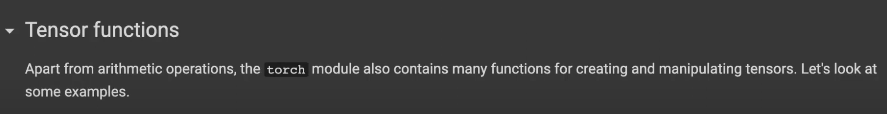

In [19]:
t6 = torch.full((3,2),42)
t6 #create a tensor with a fixed value for every element

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [21]:
#concatenate two tensors with compatible shapes
t7 = torch.cat((t3,t6))
t7

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.],
        [42., 42.],
        [42., 42.],
        [42., 42.]])

In [22]:
#compute the sin of each elements
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165]])

In [23]:
#change the shape of a tensor
t9 = t8.reshape(3,2,2)
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

## Interoperability with Numpy

[Numpy](http://www.numpy.org/) is a popular open-source library used for mathematical and scientific computing in Python. It enables efficient operations on large multi-dimensional arrays and has a vast ecosystem of supporting libraries, including:

* [Pandas](https://pandas.pydata.org/) for file I/O and data analysis
* [Matplotlib](https://matplotlib.org/) for plotting and visualization
* [OpenCV](https://opencv.org/) for image and video processing


If you're interested in learning more about Numpy and other data science libraries in Python, check out this tutorial series: https://jovian.ai/aakashns/python-numerical-computing-with-numpy .

Instead of reinventing the wheel, PyTorch interoperates well with Numpy to leverage its existing ecosystem of tools and libraries.

In [24]:
import numpy as np
x = np.array([[1,2],[3,4.]])
x

array([[1., 2.],
       [3., 4.]])

####torch.from_numpy()

In [25]:
#convert the numpy array to a torch tensor
y = torch.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [28]:
x.dtype,y.dtype #numpy and tensor have similar data types

(dtype('float64'), torch.float64)

In [29]:
#convert a torch tensor to a numpy array
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

The interoperability between PyTorch and Numpy is essential because most datasets you'll work with will likely be read and preprocessed as Numpy arrays.

You might wonder why we need a library like PyTorch at all since Numpy already provides data structures and utilities for working with multi-dimensional numeric data. There are two main reasons:

1. **Autograd**: The ability to automatically compute gradients for tensor operations is essential for training deep learning models.
2. **GPU support**: While working with massive datasets and large models, PyTorch tensor operations can be performed efficiently using a Graphics Processing Unit (GPU). Computations that might typically take hours can be completed within minutes using GPUs.

We'll leverage both these features of PyTorch extensively in this tutorial series.

## Linear Regression with PyTorch

#### Part 2 of "PyTorch: Zero to GANs"

*This post is the second in a series of tutorials on building deep learning models with PyTorch, an open source neural networks library developed and maintained by Facebook. Check out the full series:*

1. [PyTorch Basics: Tensors & Gradients](https://medium.com/jovian-io/pytorch-basics-tensors-and-gradients-eb2f6e8a6eee)
2. [Linear Regression & Gradient Descent](https://medium.com/jovian-io/linear-regression-with-pytorch-3dde91d60b50) (this post)
3. Coming soon.. (logistic regression, neural networks, CNNs, RNNs, GANs etc.)


Continuing where the [previous tutorial](https://jvn.io/aakashns/3143ceb92b4f4cbbb4f30e203580b77b) left off, we'll discuss one of the foundational  algorithms of machine learning in this post: *Linear regression*. We'll create a model that predicts crop yields for apples and oranges (*target variables*) by looking at the average temperature, rainfall and humidity (*input variables or features*) in a region. Here's the training data:

![linear-regression-training-data](https://i.imgur.com/6Ujttb4.png)

In a linear regression model, each target variable is estimated to be a weighted sum of the input variables, offset by some constant, known as a bias :

```
yield_apple  = w11 * temp + w12 * rainfall + w13 * humidity + b1
yield_orange = w21 * temp + w22 * rainfall + w23 * humidity + b2
```

Visually, it means that the yield of apples is a linear or planar function of temperature, rainfall and humidity:

![linear-regression-graph](https://i.imgur.com/4DJ9f8X.png)

The *learning* part of linear regression is to figure out a set of weights `w11, w12,... w23, b1 & b2` by looking at the training data, to make accurate predictions for new data (i.e. to predict the yields for apples and oranges in a new region using the average temperature, rainfall and humidity). This is done by adjusting the weights slightly many times to make better predictions, using an optimization technique called *gradient descent*.

In [30]:
import numpy as np
import torch

## Training data

The training data can be represented using 2 matrices: `inputs` and `targets`, each with one row per observation, and one column per variable.

In [31]:
# Input (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Targets (apples, oranges)
targets = np.array([[56, 70],
                    [81, 101],
                    [119, 133],
                    [22, 37],
                    [103, 119]], dtype='float32')

We've separated the input and target variables, because we'll operate on them separately. Also, we've created numpy arrays, because this is typically how you would work with training data: read some CSV files as numpy arrays, do some processing, and then convert them to PyTorch tensors as follows:

In [32]:
#converts inputs and targets to tensors
inputs = torch.from_numpy(inputs)
targets= torch.from_numpy(targets)
print(inputs)
print(targets)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])


In PyTorch, tensor elements are often in **float** by default because:

1. **Precision**: Floats can represent a wider range of values and are more precise for calculations, especially in machine learning.
2. **Compatibility**: Many operations, especially in neural networks, require floating-point arithmetic.
3. **Common Use**: Most machine learning algorithms work with floats, making it easier for users.

You can create tensors with other data types by specifying the `dtype`, like `torch.int32` for integers.

## Linear regression model from scratch

The weights and biases (`w11, w12,... w23, b1 & b2`) can also be represented as matrices, initialized as random values. The first row of `w` and the first element of `b` are used to predict the first target variable i.e. yield of apples, and similarly the second for oranges.

In [33]:
#weights and biases
w = torch.randn(2,3,requires_grad =True)
b = torch.randn(2,requires_grad =True)
print(w)
print(b)

tensor([[-1.4447, -1.1156,  0.1752],
        [ 0.8000, -0.6925, -1.2908]], requires_grad=True)
tensor([-0.9729,  0.9289], requires_grad=True)


`torch.randn` creates a tensor with the given shape, with elements picked randomly from a [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) with mean 0 and standard deviation 1.

Our *model* is simply a function that performs a matrix multiplication of the `inputs` and the weights `w` (transposed) and adds the bias `b` (replicated for each observation).

![matrix-mult](https://i.imgur.com/WGXLFvA.png)

We can define the model as follows:

In [34]:
def model(x):
  return x @ w.t() + b

`@` represents matrix multiplication in PyTorch, and the `.t` method returns the transpose of a tensor.

The matrix obtained by passing the input data into the model is a set of predictions for the target variables.

In [35]:
#generate predictions
preds = model(inputs)
print(preds)

tensor([[-173.6448,  -42.5764],
        [-219.3967,  -69.8267],
        [-265.9873,  -97.1360],
        [-189.8174,    4.9870],
        [-195.4872, -100.7106]], grad_fn=<AddBackward0>)


In [36]:
#compare with targets
print(targets)

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])


## Loss function

Before we improve our model, we need a way to evaluate how well our model is performing. We can compare the model's predictions with the actual targets, using the following method:

* Calculate the difference between the two matrices (`preds` and `targets`).
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.

The result is a single number, known as the **mean squared error** (MSE).

In [37]:
#MSE loss
def mse(t1,t2):
  diff = t1- t2
  return torch.sum(diff * diff) / diff.numel()

`torch.sum` returns the sum of all the elements in a tensor, and the `.numel` method returns the number of elements in a tensor. Let's compute the mean squared error for the current predictions of our model.

In [38]:
#compute loss
loss = mse(preds,targets)
print(loss)

tensor(56926.6758, grad_fn=<DivBackward0>)


Here’s how we can interpret the result: *On average, each element in the prediction differs from the actual target by about 117.2 (square root of 13742)*. And that’s pretty bad, considering the numbers we are trying to predict are themselves in the range 50–200. Also, the result is called the *loss*, because it indicates how bad the model is at predicting the target variables. Lower the loss, better the model.

## Compute gradients

With PyTorch, we can automatically compute the gradient or derivative of the loss w.r.t. to the weights and biases, because they have `requires_grad` set to `True`.

In [39]:
# Compute gradients
loss.backward()

The gradients are stored in the `.grad` property of the respective tensors. Note that the derivative of the loss w.r.t. the weights matrix is itself a matrix, with the same dimensions.

In [40]:
# Gradients for weights
print(w)
print(w.grad)

tensor([[-1.4447, -1.1156,  0.1752],
        [ 0.8000, -0.6925, -1.2908]], requires_grad=True)
tensor([[-23959.0098, -26234.4648, -16032.1445],
        [-12442.1016, -15176.4756,  -9137.1621]])


The loss is a [quadratic function](https://en.wikipedia.org/wiki/Quadratic_function) of our weights and biases, and our objective is to find the set of weights where the loss is the lowest. If we plot a graph of the loss w.r.t any individual weight or bias element, it will look like the figure shown below. A key insight from calculus is that the gradient indicates the rate of change of the loss, or the [slope](https://en.wikipedia.org/wiki/Slope) of the loss function w.r.t. the weights and biases.

If a gradient element is **positive**:
* **increasing** the element's value slightly will **increase** the loss.
* **decreasing** the element's value slightly will **decrease** the loss

![postive-gradient](https://i.imgur.com/hFYoVgU.png)

If a gradient element is **negative**:
* **increasing** the element's value slightly will **decrease** the loss.
* **decreasing** the element's value slightly will **increase** the loss.

![negative=gradient](https://i.imgur.com/w3Wii7C.png)

The increase or decrease in loss by changing a weight element is proportional to the value of the gradient of the loss w.r.t. that element. This forms the basis for the optimization algorithm that we'll use to improve our model.

Before we proceed, we reset the gradients to zero by calling `.zero_()` method. We need to do this, because PyTorch accumulates, gradients i.e. the next time we call `.backward` on the loss, the new gradient values will get added to the existing gradient values, which may lead to unexpected results.

In [41]:
w.grad.zero_()
b.grad.zero_()
print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


## Adjust weights and biases using gradient descent

We'll reduce the loss and improve our model using the gradient descent optimization algorithm, which has the following steps:

1. Generate predictions

2. Calculate the loss

3. Compute gradients w.r.t the weights and biases

4. Adjust the weights by subtracting a small quantity proportional to the gradient

5. Reset the gradients to zero

Let's implement the above step by step.

In [42]:
#generate predictions
preds = model(inputs)
print(preds)

tensor([[-173.6448,  -42.5764],
        [-219.3967,  -69.8267],
        [-265.9873,  -97.1360],
        [-189.8174,    4.9870],
        [-195.4872, -100.7106]], grad_fn=<AddBackward0>)


Note that the predictions are same as before, since we haven't made any changes to our model. The same holds true for the loss and gradients.

In [43]:
loss = mse(preds,targets)
print(loss)

tensor(56926.6758, grad_fn=<DivBackward0>)


In [44]:
#compute gradients
loss.backward()
print(w.grad)
print(b.grad)

tensor([[-23959.0098, -26234.4648, -16032.1445],
        [-12442.1016, -15176.4756,  -9137.1621]])
tensor([-285.0667, -153.0526])


Finally, we update the weights and biases using the gradients computed above.

In [45]:
# Adjust weights & reset gradients
with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5
    w.grad.zero_()
    b.grad.zero_()

A few things to note above:

* We use `torch.no_grad` to indicate to PyTorch that we shouldn't track, calculate or modify gradients while updating the weights and biases.

* We multiply the gradients with a really small number (`10^-5` in this case), to ensure that we don't modify the weights by a really large amount, since we only want to take a small step in the downhill direction of the gradient. This number is called the *learning rate* of the algorithm.

* After we have updated the weights, we reset the gradients back to zero, to avoid affecting any future computations.

In [46]:
print(w)
print(b)

tensor([[-1.2051, -0.8533,  0.3356],
        [ 0.9244, -0.5407, -1.1995]], requires_grad=True)
tensor([-0.9700,  0.9305], requires_grad=True)


With the new weights and biases, the model should have lower loss.

In [47]:
preds = model(inputs)
loss = mse(preds,targets)
print(loss)

tensor(38825.0898, grad_fn=<DivBackward0>)


We have already achieved a significant reduction in the loss, simply by adjusting the weights and biases slightly using gradient descent.

## Train for multiple epochs

To reduce the loss further, we can repeat the process of adjusting the weights and biases using the gradients multiple times. Each iteration is called an epoch. Let's train the model for 100 epochs.

In [48]:
# Train for 100 epochs
for i in range(100):
    preds = model(inputs)
    loss = mse(preds, targets)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * 1e-5
        b -= b.grad * 1e-5
        w.grad.zero_()
        b.grad.zero_()

Once again, let's verify that the loss is now lower:

In [49]:
# Calculate loss
preds = model(inputs)
loss = mse(preds, targets)
print(loss)

tensor(488.2263, grad_fn=<DivBackward0>)


As you can see, the loss is now much lower than what we started out with. Let's look at the model's predictions and compare them with the targets.

In [50]:
# Predictions
preds

tensor([[ 58.8650,  79.9195],
        [ 86.8711,  96.3345],
        [105.3495, 127.3718],
        [ 32.2476,  90.8740],
        [103.3294,  80.3493]], grad_fn=<AddBackward0>)

In [51]:
# Targets
targets

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])

The prediction are now quite close to the target variables, and we can get even better results by training for a few more epochs.

## Linear regression using PyTorch built-ins

The model and training process above were implemented using basic matrix operations. But since this such a common pattern , PyTorch has several built-in functions and classes to make it easy to create and train models.

Let's begin by importing the `torch.nn` package from PyTorch, which contains utility classes for building neural networks.

In [52]:
import torch.nn as nn


As before, we represent the inputs and targets and matrices.

In [53]:
# Input (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43], [91, 88, 64], [87, 134, 58],
                   [102, 43, 37], [69, 96, 70], [73, 67, 43],
                   [91, 88, 64], [87, 134, 58], [102, 43, 37],
                   [69, 96, 70], [73, 67, 43], [91, 88, 64],
                   [87, 134, 58], [102, 43, 37], [69, 96, 70]],
                  dtype='float32')

# Targets (apples, oranges)
targets = np.array([[56, 70], [81, 101], [119, 133],
                    [22, 37], [103, 119], [56, 70],
                    [81, 101], [119, 133], [22, 37],
                    [103, 119], [56, 70], [81, 101],
                    [119, 133], [22, 37], [103, 119]],
                   dtype='float32')

inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets)

We are using 15 training examples this time, to illustrate how to work with large datasets in small batches.

## Dataset and DataLoader

We'll create a `TensorDataset`, which allows access to rows from `inputs` and `targets` as tuples, and provides standard APIs for working with many different types of datasets in PyTorch.

In [54]:
from torch.utils.data import TensorDataset

In [55]:
#Define dataset
train_ds = TensorDataset(inputs,targets)
train_ds[0:3]

(tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [ 87., 134.,  58.]]),
 tensor([[ 56.,  70.],
         [ 81., 101.],
         [119., 133.]]))

The `TensorDataset` allows us to access a small section of the training data using the array indexing notation (`[0:3]` in the above code). It returns a tuple (or pair), in which the first element contains the input variables for the selected rows, and the second contains the targets.

We'll also create a `DataLoader`, which can split the data into batches of a predefined size while training. It also provides other utilities like shuffling and random sampling of the data.

In [56]:
from torch.utils.data import DataLoader

In [57]:
# Define data loader
batch_size = 5
train_dl = DataLoader(train_ds, batch_size, shuffle=True)


The data loader is typically used in a `for-in` loop. Let's look at an example.

In [58]:
for xb,yb in train_dl:
  print(xb)
  print(yb)
  break

tensor([[ 87., 134.,  58.],
        [ 69.,  96.,  70.],
        [ 73.,  67.,  43.],
        [ 87., 134.,  58.],
        [ 73.,  67.,  43.]])
tensor([[119., 133.],
        [103., 119.],
        [ 56.,  70.],
        [119., 133.],
        [ 56.,  70.]])


In each iteration, the data loader returns one batch of data, with the given batch size. If `shuffle` is set to `True`, it shuffles the training data before creating batches. Shuffling helps randomize the input to the optimization algorithm, which can lead to faster reduction in the loss.

## nn.Linear

Instead of initializing the weights & biases manually, we can define the model using the `nn.Linear` class from PyTorch, which does it automatically.

In [59]:
#define model
model = nn.Linear(3,2)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[ 0.0605,  0.0990,  0.0590],
        [-0.4210, -0.4354, -0.5722]], requires_grad=True)
Parameter containing:
tensor([ 0.3457, -0.5532], requires_grad=True)


PyTorch models also have a helpful `.parameters` method, which returns a list containing all the weights and bias matrices present in the model. For our linear regression model, we have one weight matrix and one bias matrix.

In [60]:
#Parameters
list(model.parameters())

[Parameter containing:
 tensor([[ 0.0605,  0.0990,  0.0590],
         [-0.4210, -0.4354, -0.5722]], requires_grad=True),
 Parameter containing:
 tensor([ 0.3457, -0.5532], requires_grad=True)]

We can use the model to generate predictions in the exact same way as before:

In [61]:
#Generate predictions
preds =model(inputs)
preds


tensor([[  13.9325,  -85.0625],
        [  18.3401, -113.8001],
        [  22.2986, -128.7138],
        [  12.9555,  -83.3868],
        [  18.1562, -111.4554],
        [  13.9325,  -85.0625],
        [  18.3401, -113.8001],
        [  22.2986, -128.7138],
        [  12.9555,  -83.3868],
        [  18.1562, -111.4554],
        [  13.9325,  -85.0625],
        [  18.3401, -113.8001],
        [  22.2986, -128.7138],
        [  12.9555,  -83.3868],
        [  18.1562, -111.4554]], grad_fn=<AddmmBackward0>)

## Loss Function

Instead of defining a loss function manually, we can use the built-in loss function `mse_loss`.

In [62]:
#import nn.funcctional
import torch.nn.functional as F

The `nn.functional` package contains many useful loss functions and several other utilities.

In [63]:
loss_fn = F.mse_loss


In [64]:
loss= loss_fn(model(inputs),targets)
print(loss)

tensor(22860.7598, grad_fn=<MseLossBackward0>)


## Optimizer

Instead of manually manipulating the model's weights & biases using gradients, we can use the optimizer `optim.SGD`. SGD stands for `stochastic gradient descent`. It is called `stochastic` because samples are selected in batches (often with random shuffling) instead of as a single group.

In [65]:
# Define optimizer
opt = torch.optim.SGD(model.parameters(), lr=1e-5)

Note that `model.parameters()` is passed as an argument to `optim.SGD`, so that the optimizer knows which matrices should be modified during the update step. Also, we can specify a learning rate which controls the amount by which the parameters are modified.

## Train the model

We are now ready to train the model. We'll follow the exact same process to implement gradient descent:

1. Generate predictions

2. Calculate the loss

3. Compute gradients w.r.t the weights and biases

4. Adjust the weights by subtracting a small quantity proportional to the gradient

5. Reset the gradients to zero

The only change is that we'll work batches of data, instead of processing the entire training data in every iteration. Let's define a utility function `fit` which trains the model for a given number of epochs.

In [66]:
# Utility function to train the model
def fit(num_epochs, model, loss_fn, opt):

    # Repeat for given number of epochs
    for epoch in range(num_epochs):

        # Train with batches of data
        for xb,yb in train_dl:

            # 1. Generate predictions
            pred = model(xb)

            # 2. Calculate loss
            loss = loss_fn(pred, yb)

            # 3. Compute gradients
            loss.backward()

            # 4. Update parameters using gradients
            opt.step()

            # 5. Reset the gradients to zero
            opt.zero_grad()

        # Print the progress
        if (epoch+1) % 10 == 0:
            print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

Some things to note above:

* We use the data loader defined earlier to get batches of data for every iteration.

* Instead of updating parameters (weights and biases) manually, we use `opt.step` to perform the update, and `opt.zero_grad` to reset the gradients to zero.

* We've also added a log statement which prints the loss from the last batch of data for every 10th epoch, to track the progress of training. `loss.item` returns the actual value stored in the loss tensor.

Let's train the model for 100 epochs.

In [67]:
fit(100, model, loss_fn, opt)

Epoch [10/100], Loss: 360.5821
Epoch [20/100], Loss: 99.0809
Epoch [30/100], Loss: 299.6786
Epoch [40/100], Loss: 90.5691
Epoch [50/100], Loss: 102.2901
Epoch [60/100], Loss: 122.7263
Epoch [70/100], Loss: 36.2888
Epoch [80/100], Loss: 75.1545
Epoch [90/100], Loss: 23.4076
Epoch [100/100], Loss: 35.4094


Let's generate predictions using our model and verify that they're close to our targets.

In [68]:
# Generate predictions
preds = model(inputs)
preds

tensor([[ 58.4870,  71.7618],
        [ 80.8949,  96.9973],
        [119.5741, 139.3318],
        [ 28.1900,  45.2365],
        [ 95.5562, 107.8173],
        [ 58.4870,  71.7618],
        [ 80.8949,  96.9973],
        [119.5741, 139.3318],
        [ 28.1900,  45.2365],
        [ 95.5562, 107.8173],
        [ 58.4870,  71.7618],
        [ 80.8949,  96.9973],
        [119.5741, 139.3318],
        [ 28.1900,  45.2365],
        [ 95.5562, 107.8173]], grad_fn=<AddmmBackward0>)

In [69]:
# Compare with targets
targets

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.],
        [ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.],
        [ 56.,  70.],
        [ 81., 101.],
        [119., 133.],
        [ 22.,  37.],
        [103., 119.]])

Indeed, the predictions are quite close to our targets, and now we have a fairly good model to predict crop yields for apples and oranges by looking at the average temperature, rainfall and humidity in a region.